<a href="https://colab.research.google.com/github/AditiBande58/Breast-Cancer-ML-Project/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [6]:
!pip install ucimlrepo

In [7]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [8]:
#Load data into dataframe
DATA_URL = 'https://raw.githubusercontent.com/AditiBande58/Breast-Cancer-ML-Project/refs/heads/main/breast%2Bcancer%2Bwisconsin%2Bdiagnostic/wdbc.data'
df = pd.read_csv(DATA_URL, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension'
]

# Create explicit column names for mean, standard error (se), and worst values
col_names = ['id', 'diagnosis']
for stat in ['mean', 'se', 'worst']:
    for feature in features:
        col_names.append(f'{feature}_{stat}')

# Assign names to the DataFrame
df.columns = col_names
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
print(df.shape)

(569, 32)


In [12]:
# check for nulls or duplicates to clean the data
print("Nulls per column:")
print(df.isnull().sum())

n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after de-duplication: {df.shape}")

Nulls per column:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Duplicate rows: 0
Shape after de-duplica

In [14]:
# Drop the 'id' column as it is not a predictive feature
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Encode the target 'diagnosis' variable: Malignant (M) -> 1, Benign (B) -> 0
if df['diagnosis'].dtype == 'object':
    df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Display the prepared dataset
print(f"New shape of the dataset: {df.shape}")
display(df.head())

New shape of the dataset: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


--- Shapiro-Wilk Normality Test Results (p > 0.05 suggests normality) ---
radius_mean               | W-Statistic: 0.9411 | p-value: 3.1056e-14 | Normal? No
texture_mean              | W-Statistic: 0.9767 | p-value: 7.2836e-08 | Normal? No
perimeter_mean            | W-Statistic: 0.9362 | p-value: 7.0114e-15 | Normal? No
area_mean                 | W-Statistic: 0.8584 | p-value: 3.1963e-22 | Normal? No
smoothness_mean           | W-Statistic: 0.9875 | p-value: 8.6008e-05 | Normal? No
compactness_mean          | W-Statistic: 0.9170 | p-value: 3.9672e-17 | Normal? No
concavity_mean            | W-Statistic: 0.8668 | p-value: 1.3386e-21 | Normal? No
concave_points_mean       | W-Statistic: 0.8917 | p-value: 1.4046e-19 | Normal? No
symmetry_mean             | W-Statistic: 0.9726 | p-value: 7.8848e-09 | Normal? No
fractal_dimension_mean    | W-Statistic: 0.9233 | p-value: 1.9566e-16 | Normal? No


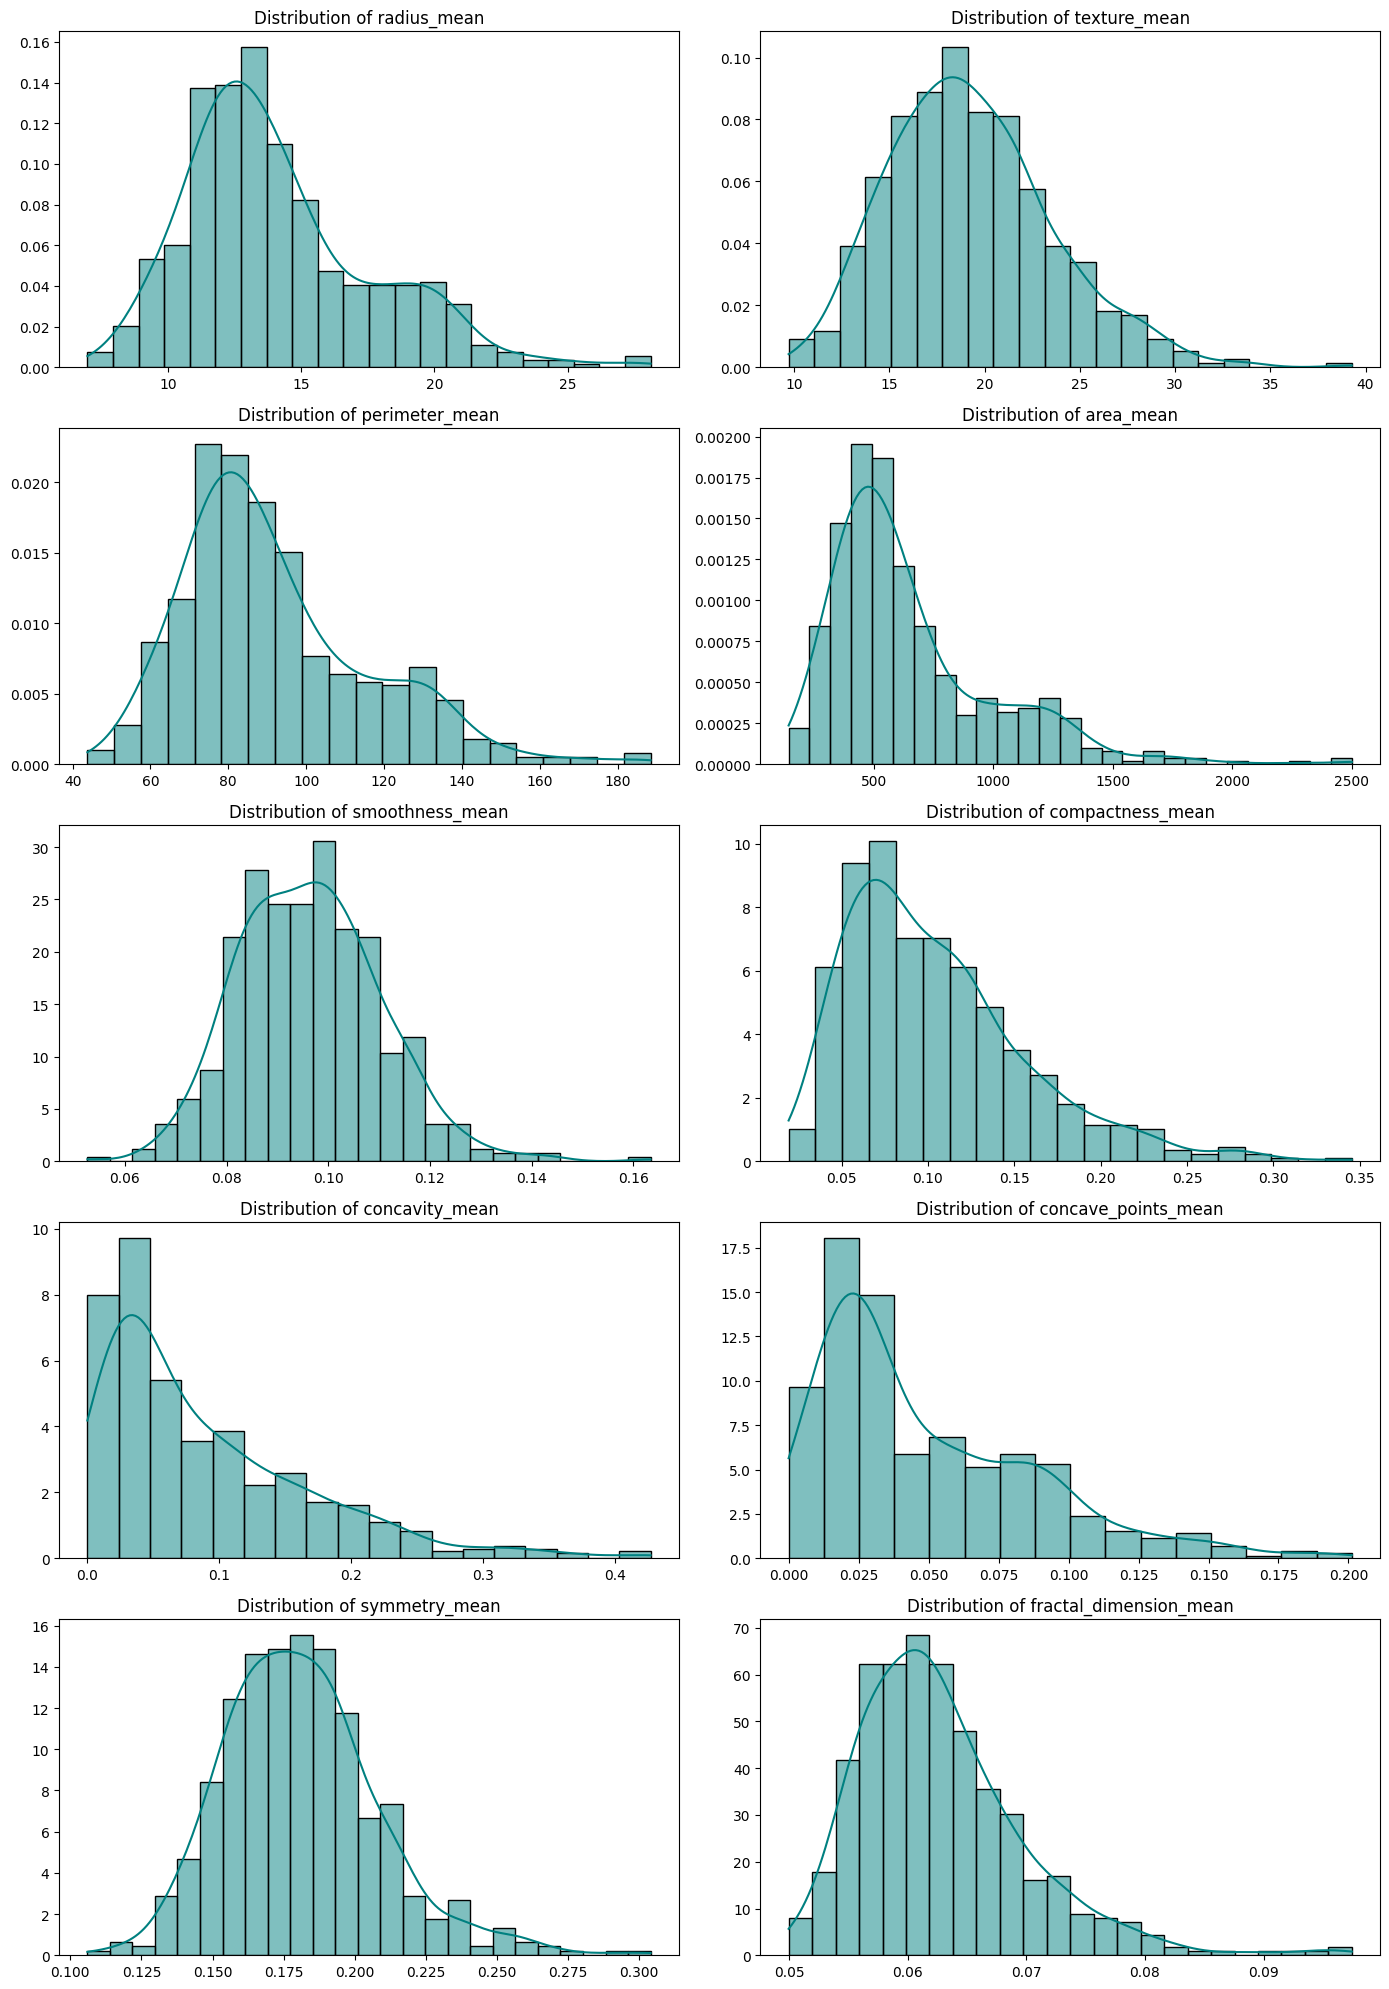

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Filter the 10 main 'mean' features
mean_cols = [col for col in df.columns if col.endswith('_mean')]

# Set up the plotting grid (5 rows, 2 columns)
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

print("--- Shapiro-Wilk Normality Test Results (p > 0.05 suggests normality) ---")
for i, col in enumerate(mean_cols):
    # Plot histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', stat="density")
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # Statistical test for normality
    stat, p_val = shapiro(df[col].dropna())
    print(f"{col:<25} | W-Statistic: {stat:.4f} | p-value: {p_val:.4e} | Normal? {'Yes' if p_val > 0.05 else 'No'}")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Separate features (X_df) and target (y_df)
X_df = df.drop(columns=['diagnosis'])
y_df = df['diagnosis']

# 1. Standardization (Mean=0, Std=1) - Ideal for SVM, Logistic Regression, etc.
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X_df), columns=X_df.columns)

# 2. Normalization (Min=0, Max=1) - Useful when bounds are preferred
scaler_minmax = MinMaxScaler()
X_norm = pd.DataFrame(scaler_minmax.fit_transform(X_df), columns=X_df.columns)

print("Features successfully standardized (X_std) and normalized (X_norm).")
print("X_std Summary (First 3 columns showing mean≈0, std≈1):")
display(X_std.iloc[:, :3].describe())

Features successfully standardized (X_std) and normalized (X_norm).
X_std Summary (First 3 columns showing mean≈0, std≈1):


,radius_mean,texture_mean,perimeter_mean
count,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.373633e-16,6.868164e-17,-1.248757e-16
std,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01
max,3.971288e+00,4.651889e+00,3.976130e+00


In [21]:
import numpy as np

# Calculate correlation of all features with the target 'diagnosis'
correlations = df.corr()['diagnosis'].sort_values(ascending=False)

print("--- Correlation of Features with Target (Diagnosis) ---")
print(correlations)

--- Correlation of Features with Target (Diagnosis) ---
diagnosis                  1.000000
concave_points_worst       0.793566
perimeter_worst            0.782914
concave_points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave_points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_

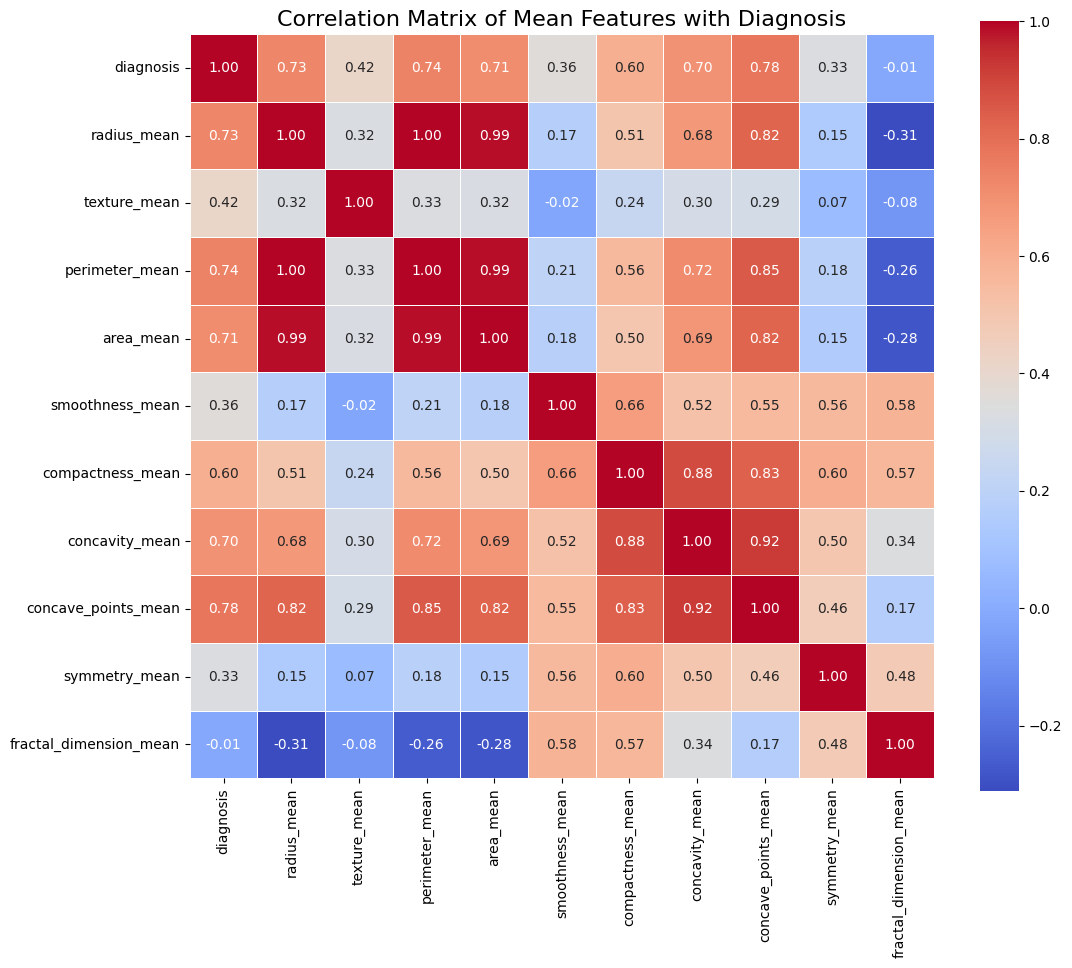

In [19]:
# Visualizing the correlation matrix of the 'mean' features
mean_cols_with_target = ['diagnosis'] + mean_cols
corr_matrix_mean = df[mean_cols_with_target].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_mean, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Mean Features with Diagnosis', fontsize=16)
plt.show()

Decision Tree

In [23]:
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score

# one representative per correlated cluster
feature_cols = ["concave_points_worst", "perimeter_worst", "texture_worst", "smoothness_worst"]
X = df[feature_cols]
y = df["diagnosis"]

# Split (stratified; test set untouched until the end)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

#Baseline: untuned tree
base = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("Train accuracy:", accuracy_score(y_train, base.predict(X_train)))
print("Test accuracy: ", accuracy_score(y_test, base.predict(X_test)))
print("Depth:", base.get_depth(), "| Leaves:", base.get_n_leaves())

# How many features? (CV on train only)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ordered = ["concave_points_worst", "perimeter_worst", "texture_worst",
           "smoothness_worst", "radius_worst"]   # radius_worst = redundant control

rows = []
for k in range(1, len(ordered) + 1):
    cols = ordered[:k]
    m = DecisionTreeClassifier(max_depth=4, random_state=42)
    Xk = df.loc[X_train.index, cols]
    rows.append({
        "n_features": k, "added": cols[-1],
        "cv_accuracy": cross_val_score(m, Xk, y_train, cv=cv, scoring="accuracy").mean(),
        "cv_recall":   cross_val_score(m, Xk, y_train, cv=cv, scoring="recall").mean(),
    })
print(pd.DataFrame(rows).round(4))

# GridSearchCV
params = {
    "max_depth": [2, 3, 4, 5, 6, 7, 9, None],
    "min_samples_leaf": [1, 2, 3, 5, 8, 12],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0.0, 0.005, 0.01, 0.02],
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    scoring={"accuracy": "accuracy", "recall": "recall", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
gs_dt.fit(X_train, y_train)    # train only

print("Best params:", gs_dt.best_params_)
print("Best CV F1 :", round(gs_dt.best_score_, 4))

# Evidence the best params are really best
res = pd.DataFrame(gs_dt.cv_results_)
cols = ["params", "mean_test_f1", "std_test_f1", "mean_test_recall",
        "mean_test_accuracy", "mean_train_f1", "rank_test_f1"]
pd.set_option("display.max_colwidth", 120)
print(res.sort_values("rank_test_f1").head(10)[cols].round(4))



Train accuracy: 1.0
Test accuracy:  0.9122807017543859
Depth: 6 | Leaves: 17
   n_features                 added  cv_accuracy  cv_recall
0           1  concave_points_worst       0.9096     0.8310
1           2       perimeter_worst       0.9397     0.8852
2           3         texture_worst       0.9523     0.9324
3           4      smoothness_worst       0.9598     0.9590
4           5          radius_worst       0.9598     0.9324
Best params: {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}
Best CV F1 : 0.9501
                                                                                                        params  \
61      {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5}   
60      {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2}   
37      {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1

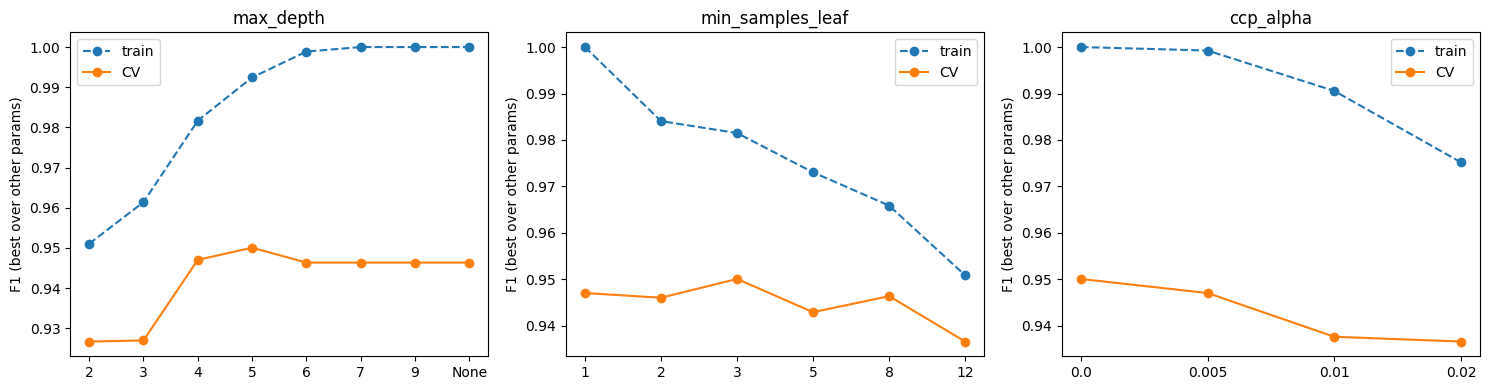

Decision Tree Model Report:
accuracy = 0.9239766081871345
              precision    recall  f1-score   support

      Benign       0.93      0.95      0.94       107
   Malignant       0.92      0.88      0.90        64

    accuracy                           0.92       171
   macro avg       0.92      0.91      0.92       171
weighted avg       0.92      0.92      0.92       171

[[102   5]
 [  8  56]]
Baseline recall: 0.8438 | Tuned recall: 0.875


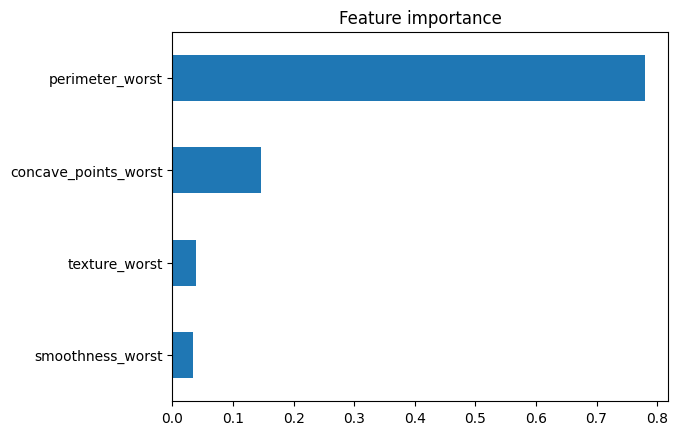

In [24]:
# sensitivity if performance is flat around the chosen value
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, ["max_depth", "min_samples_leaf", "ccp_alpha"]):
    g = res.assign(v=res.params.apply(lambda d: str(d[p]))).groupby("v", sort=False)
    m = g[["mean_test_f1", "mean_train_f1"]].max()
    ax.plot(m.index, m.mean_train_f1, "o--", label="train")
    ax.plot(m.index, m.mean_test_f1, "o-", label="CV")
    ax.set_title(p); ax.set_ylabel("F1 (best over other params)"); ax.legend()
plt.tight_layout(); plt.show()

# Final test-set evaluation
best_dt = gs_dt.best_estimator_
y_pred = best_dt.predict(X_test)

print("Decision Tree Model Report:")
print("accuracy = " + str(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))
print(confusion_matrix(y_test, y_pred))
print("Baseline recall:", round(recall_score(y_test, base.predict(X_test)), 4),
      "| Tuned recall:", round(recall_score(y_test, y_pred), 4))

# Tree and importances
dot_data = export_graphviz(best_dt, out_file=None,
                           feature_names=feature_cols, class_names=["Benign", "Malignant"],
                           filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph   # last line of a cell to render

pd.Series(best_dt.feature_importances_, index=feature_cols).sort_values().plot.barh(title="Feature importance")
plt.show()

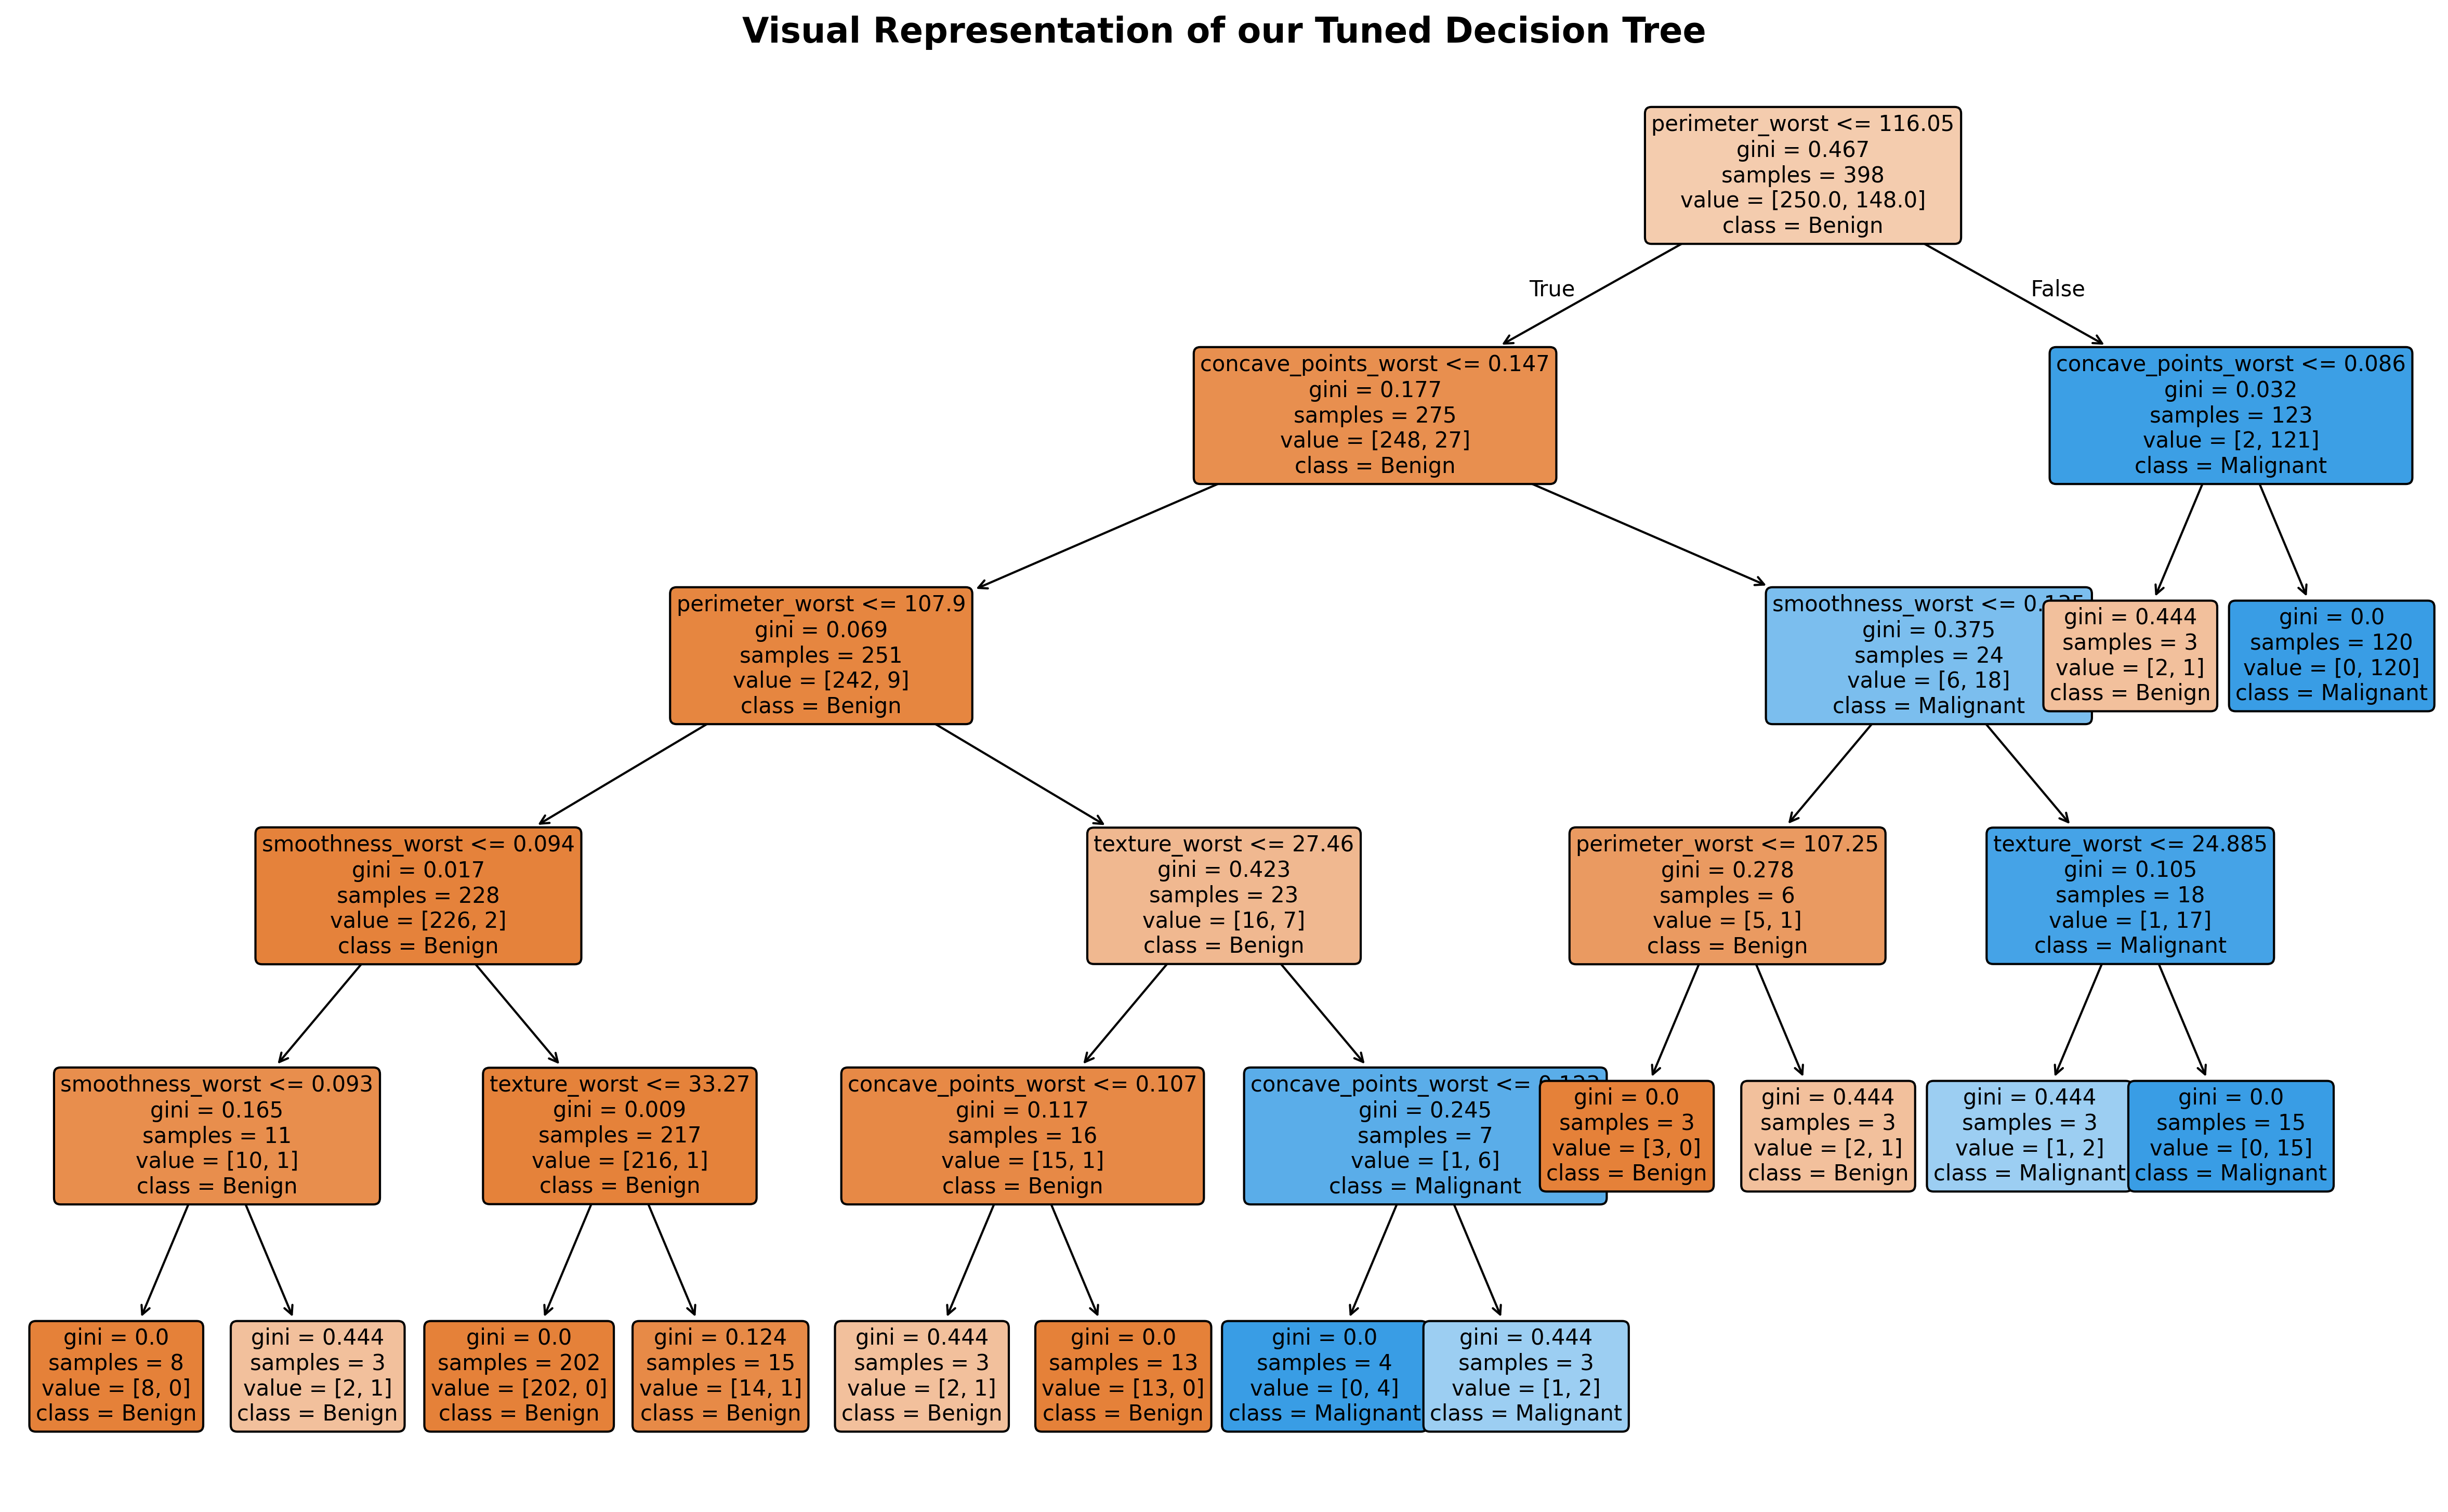

In [46]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configure a larger figure size for readability
plt.figure(figsize=(20, 12), dpi=300)

# Plot the decision tree structure
plot_tree(
    best_dt,
    feature_names=feature_cols,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Visual Representation of our Tuned Decision Tree", fontsize=16, fontweight='bold')
plt.show()

Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# 1. Baseline Random Forest with default/reasonable settings
rf_base = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print("Baseline Random Forest:")
print("Train accuracy:", accuracy_score(y_train, rf_base.predict(X_train)))
print("Test accuracy: ", accuracy_score(y_test, rf_base.predict(X_test)))
print("Number of Trees:", rf_base.n_estimators)

Baseline Random Forest:
Train accuracy: 0.9974874371859297
Test accuracy:  0.9298245614035088
Number of Trees: 100


In [27]:
# 2. Setup GridSearchCV for Random Forest
# I tune max_depth, min_samples_leaf, min_samples_split, criterion, and n_estimators
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_leaf": [1, 2, 3, 5],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    scoring={"accuracy": "accuracy", "recall": "recall", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
gs_rf.fit(X_train, y_train)

print("Best params:", gs_rf.best_params_)
print("Best CV F1 :", round(gs_rf.best_score_, 4))

Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 : 0.9498


In [28]:
# 3. Evidence of best parameters
res_rf = pd.DataFrame(gs_rf.cv_results_)
cols_rf = ["params", "mean_test_f1", "std_test_f1", "mean_test_recall",
            "mean_test_accuracy", "mean_train_f1", "rank_test_f1"]

pd.set_option("display.max_colwidth", 120)
print("--- Top 10 Random Forest Configurations by F1 Score ---")
display(res_rf.sort_values("rank_test_f1").head(10)[cols_rf].round(4))

--- Top 10 Random Forest Configurations by F1 Score ---


,params,mean_test_f1,std_test_f1,mean_test_recall,mean_test_accuracy,mean_train_f1,rank_test_f1
185,"{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}",0.9498,0.0367,0.9529,0.9624,0.9962,1
204,"{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 50}",0.9498,0.0338,0.9529,0.9624,0.9808,2
168,"{'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 50}",0.9498,0.0338,0.9529,0.9624,0.9801,2
342,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 50}",0.9489,0.0416,0.9462,0.9624,0.9826,4
348,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 50}",0.9489,0.0416,0.9462,0.9624,0.9819,4
345,"{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 50}",0.9489,0.0416,0.9462,0.9624,0.9826,4
362,"{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}",0.9470,0.0290,0.9529,0.9599,1.0000,7
361,"{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}",0.9470,0.0290,0.9529,0.9599,0.9992,7
399,"{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}",0.9468,0.0363,0.9529,0.9599,0.9966,9
373,"{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}",0.9468,0.0363,0.9529,0.9599,0.9883,9


In [29]:
# 4. Final Evaluation on Holdout Test Set
best_rf = gs_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("Random Forest Model Report:")
print("accuracy = " + str(accuracy_score(y_test, y_pred_rf)))
print(classification_report(y_test, y_pred_rf, target_names=["Benign", "Malignant"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Baseline Recall:", round(recall_score(y_test, rf_base.predict(X_test)), 4),
      "| Tuned Recall:", round(recall_score(y_test, y_pred_rf), 4))

Random Forest Model Report:
accuracy = 0.9298245614035088
              precision    recall  f1-score   support

      Benign       0.93      0.96      0.94       107
   Malignant       0.93      0.88      0.90        64

    accuracy                           0.93       171
   macro avg       0.93      0.92      0.92       171
weighted avg       0.93      0.93      0.93       171

Confusion Matrix:
[[103   4]
 [  8  56]]
Baseline Recall: 0.8594 | Tuned Recall: 0.875


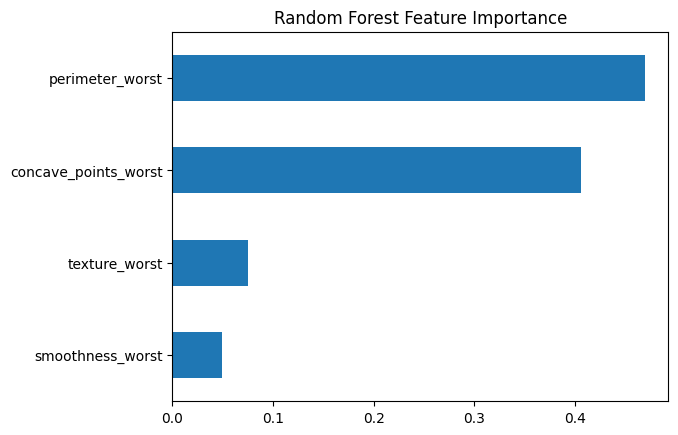

In [30]:
# 5. Feature Importances
pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values().plot.barh(title="Random Forest Feature Importance")
plt.show()

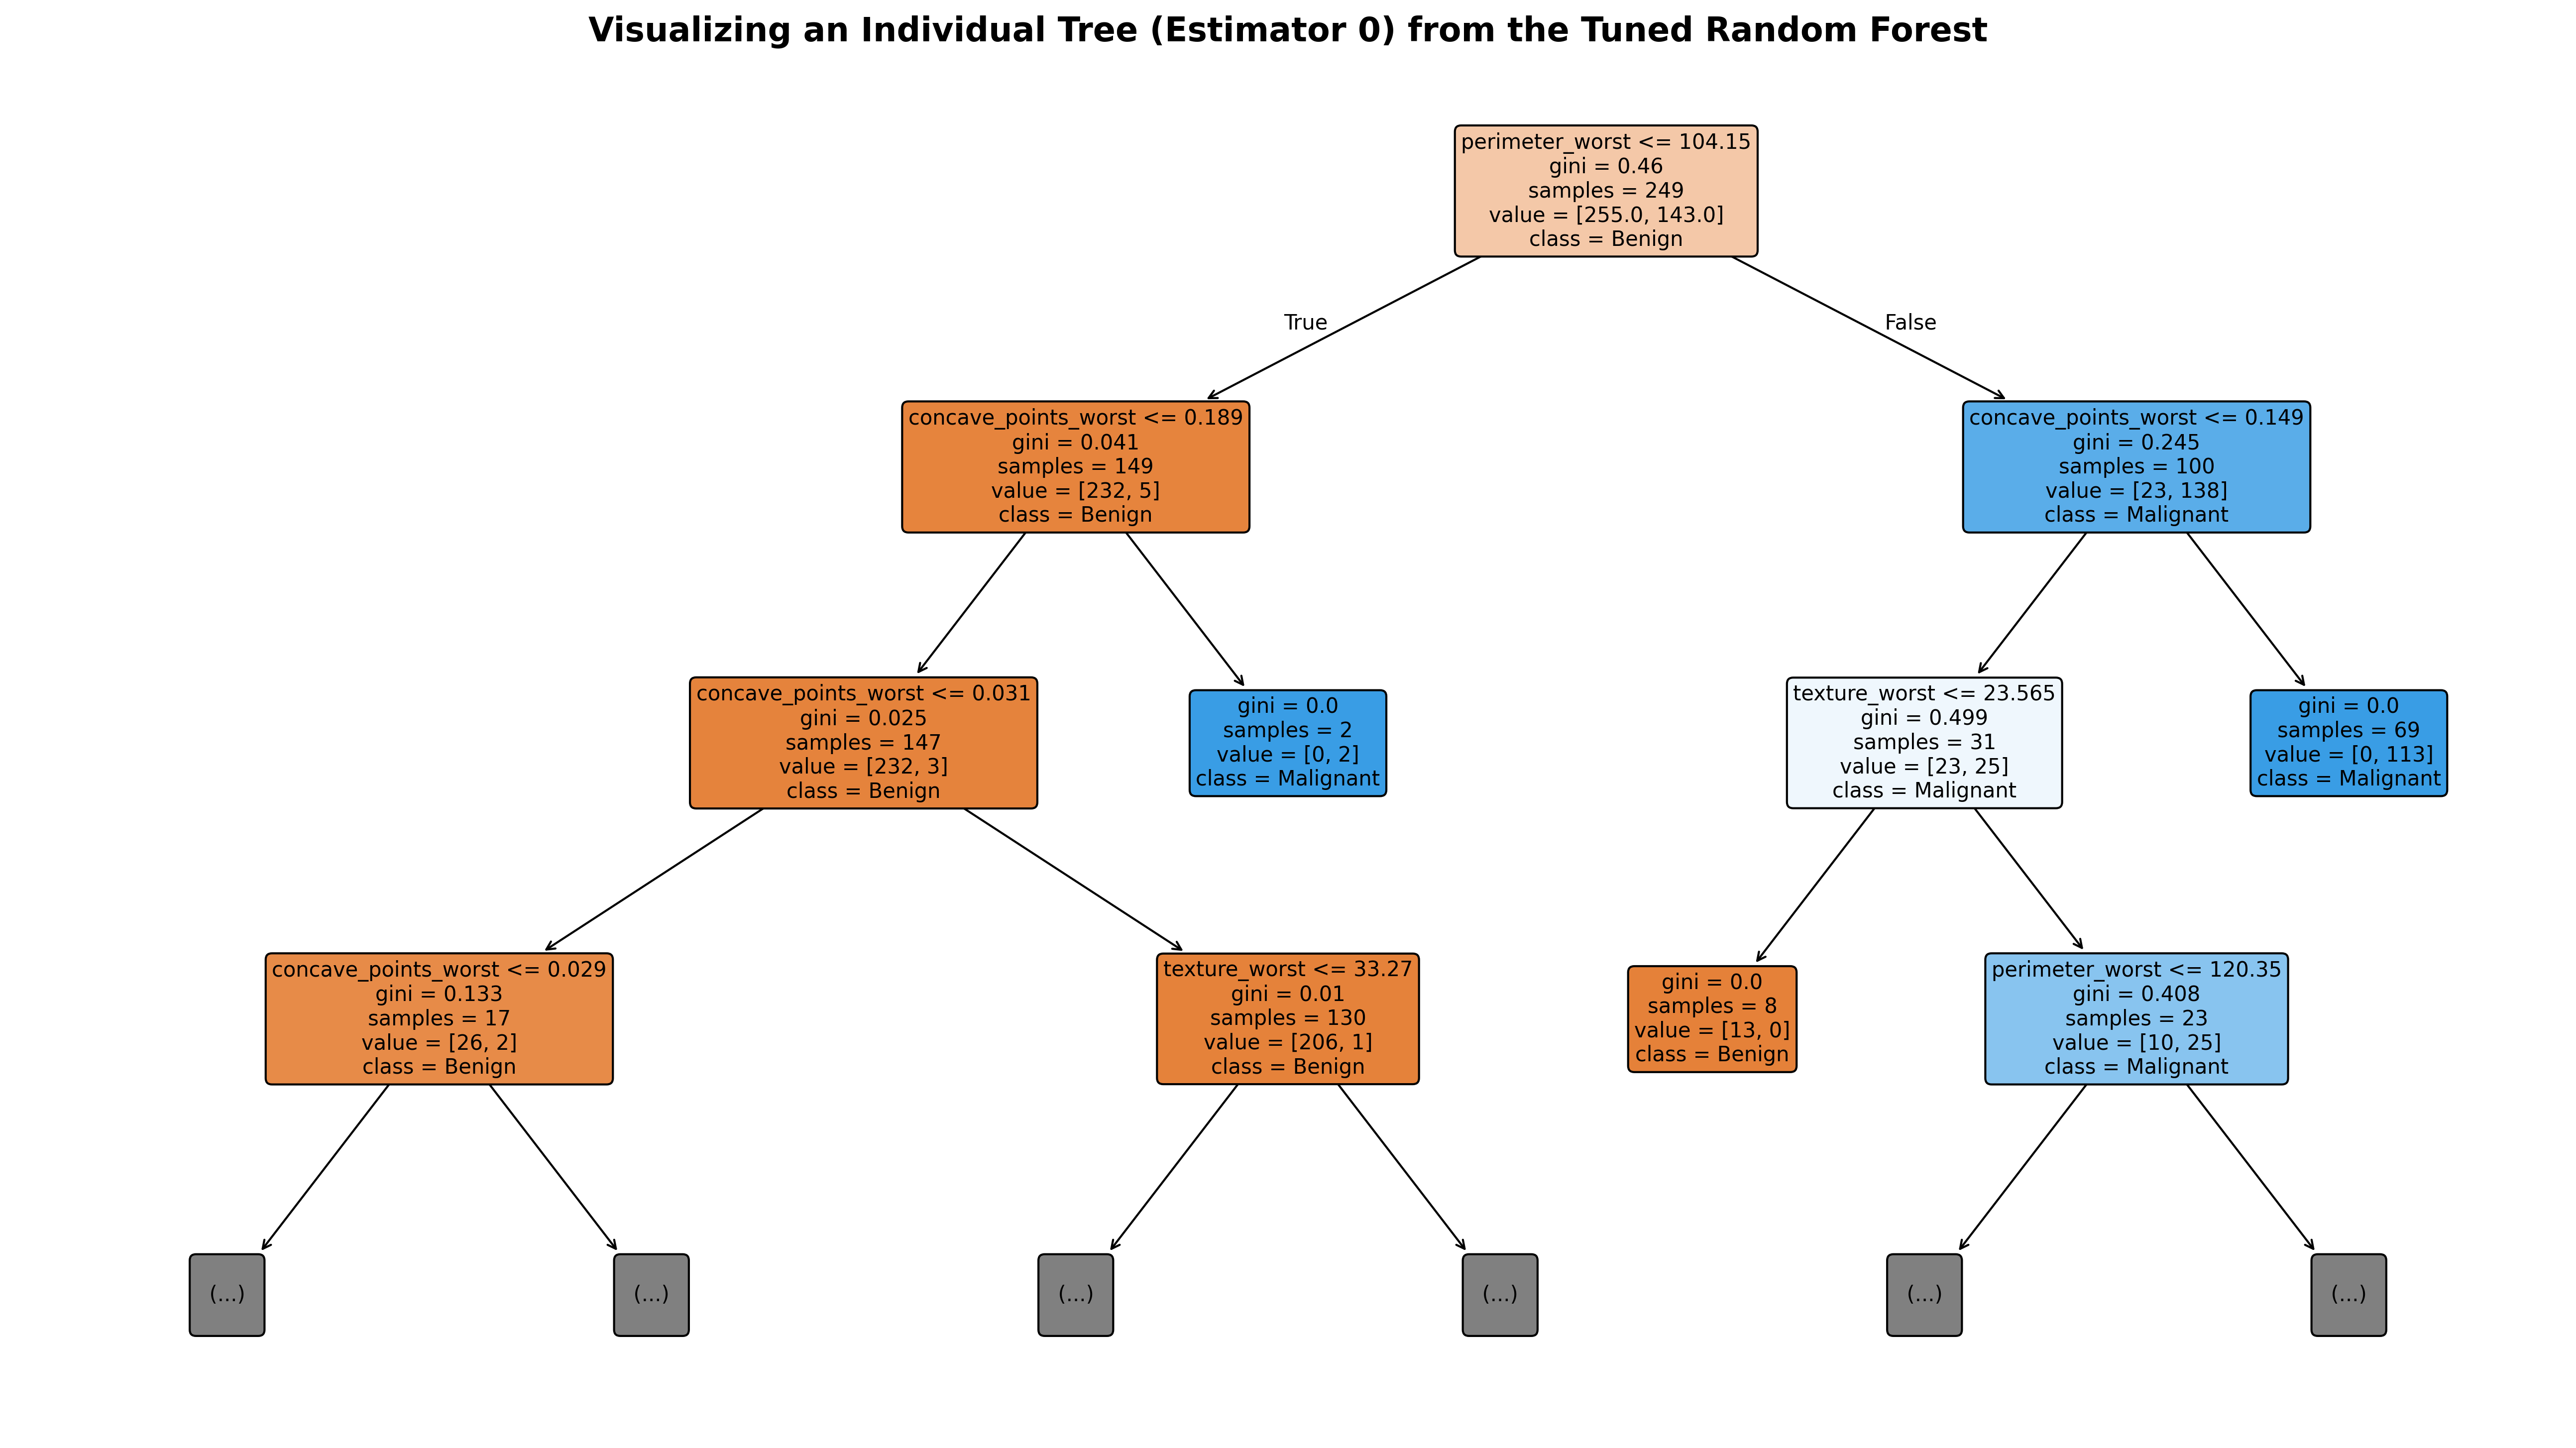

In [47]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configure a larger figure size for readability
plt.figure(figsize=(22, 12), dpi=300)

# Extract and plot the first individual tree (estimator) from the optimal Random Forest
first_rf_tree = best_rf.estimators_[0]

plot_tree(
    first_rf_tree,
    feature_names=feature_cols,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # Limit depth slightly for visual clarity
)

plt.title("Visualizing an Individual Tree (Estimator 0) from the Tuned Random Forest", fontsize=16, fontweight='bold')
plt.show()

Adaboost

In [31]:
from sklearn.ensemble import AdaBoostClassifier

# 1. Baseline AdaBoost with default settings
ada_base = AdaBoostClassifier(random_state=42).fit(X_train, y_train)
print("Baseline AdaBoost:")
print("Train accuracy:", accuracy_score(y_train, ada_base.predict(X_train)))
print("Test accuracy: ", accuracy_score(y_test, ada_base.predict(X_test)))
print("Number of estimators:", ada_base.n_estimators)

Baseline AdaBoost:
Train accuracy: 0.9974874371859297
Test accuracy:  0.9298245614035088
Number of estimators: 50


In [32]:
# 2. Setup GridSearchCV for AdaBoost
ada_params = {
    "n_estimators": [10, 50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "algorithm": ["SAMME", "SAMME.R"]
}

gs_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid=ada_params,
    scoring={"accuracy": "accuracy", "recall": "recall", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
gs_ada.fit(X_train, y_train)

print("Best params:", gs_ada.best_params_)
print("Best CV F1 :", round(gs_ada.best_score_, 4))

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
250 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
250 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_

Best params: {'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 200}
Best CV F1 : 0.9692


In [33]:
# 3. Evidence of best parameters
res_ada = pd.DataFrame(gs_ada.cv_results_)
cols_ada = ["params", "mean_test_f1", "std_test_f1", "mean_test_recall",
            "mean_test_accuracy", "mean_train_f1", "rank_test_f1"]

pd.set_option("display.max_colwidth", 120)
print("--- Top 10 AdaBoost Configurations by F1 Score ---")
display(res_ada.sort_values("rank_test_f1").head(10)[cols_ada].round(4))

--- Top 10 AdaBoost Configurations by F1 Score ---


,params,mean_test_f1,std_test_f1,mean_test_recall,mean_test_accuracy,mean_train_f1,rank_test_f1
18,"{'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 200}",0.9692,0.0321,0.9595,0.9774,0.9996,1
19,"{'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 300}",0.9692,0.0321,0.9595,0.9774,1.0000,1
21,"{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 50}",0.9652,0.0309,0.9462,0.9749,0.9947,3
24,"{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 300}",0.9627,0.0240,0.9595,0.9724,1.0000,4
17,"{'algorithm': 'SAMME', 'learning_rate': 0.5, 'n_estimators': 100}",0.9615,0.0458,0.9462,0.9724,0.9913,5
22,"{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 100}",0.9595,0.0324,0.9529,0.9699,1.0000,6
23,"{'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}",0.9590,0.0260,0.9529,0.9699,1.0000,7
14,"{'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 300}",0.9512,0.0421,0.9324,0.9649,0.9799,8
9,"{'algorithm': 'SAMME', 'learning_rate': 0.05, 'n_estimators': 300}",0.9484,0.0418,0.9390,0.9624,0.9734,9
13,"{'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 200}",0.9481,0.0417,0.9324,0.9624,0.9749,10


In [34]:
# 4. Final Evaluation on Holdout Test Set
best_ada = gs_ada.best_estimator_
y_pred_ada = best_ada.predict(X_test)

print("AdaBoost Model Report:")
print("accuracy = " + str(accuracy_score(y_test, y_pred_ada)))
print(classification_report(y_test, y_pred_ada, target_names=["Benign", "Malignant"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))
print("Baseline Recall:", round(recall_score(y_test, ada_base.predict(X_test)), 4),
      "| Tuned Recall:", round(recall_score(y_test, y_pred_ada), 4))

AdaBoost Model Report:
accuracy = 0.9181286549707602
              precision    recall  f1-score   support

      Benign       0.90      0.97      0.94       107
   Malignant       0.95      0.83      0.88        64

    accuracy                           0.92       171
   macro avg       0.93      0.90      0.91       171
weighted avg       0.92      0.92      0.92       171

Confusion Matrix:
[[104   3]
 [ 11  53]]
Baseline Recall: 0.8594 | Tuned Recall: 0.8281


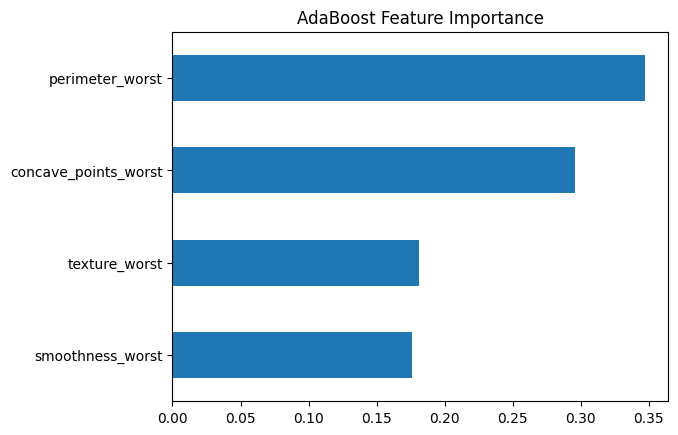

In [35]:
# 5. Feature Importances
pd.Series(best_ada.feature_importances_, index=feature_cols).sort_values().plot.barh(title="AdaBoost Feature Importance")
plt.show()

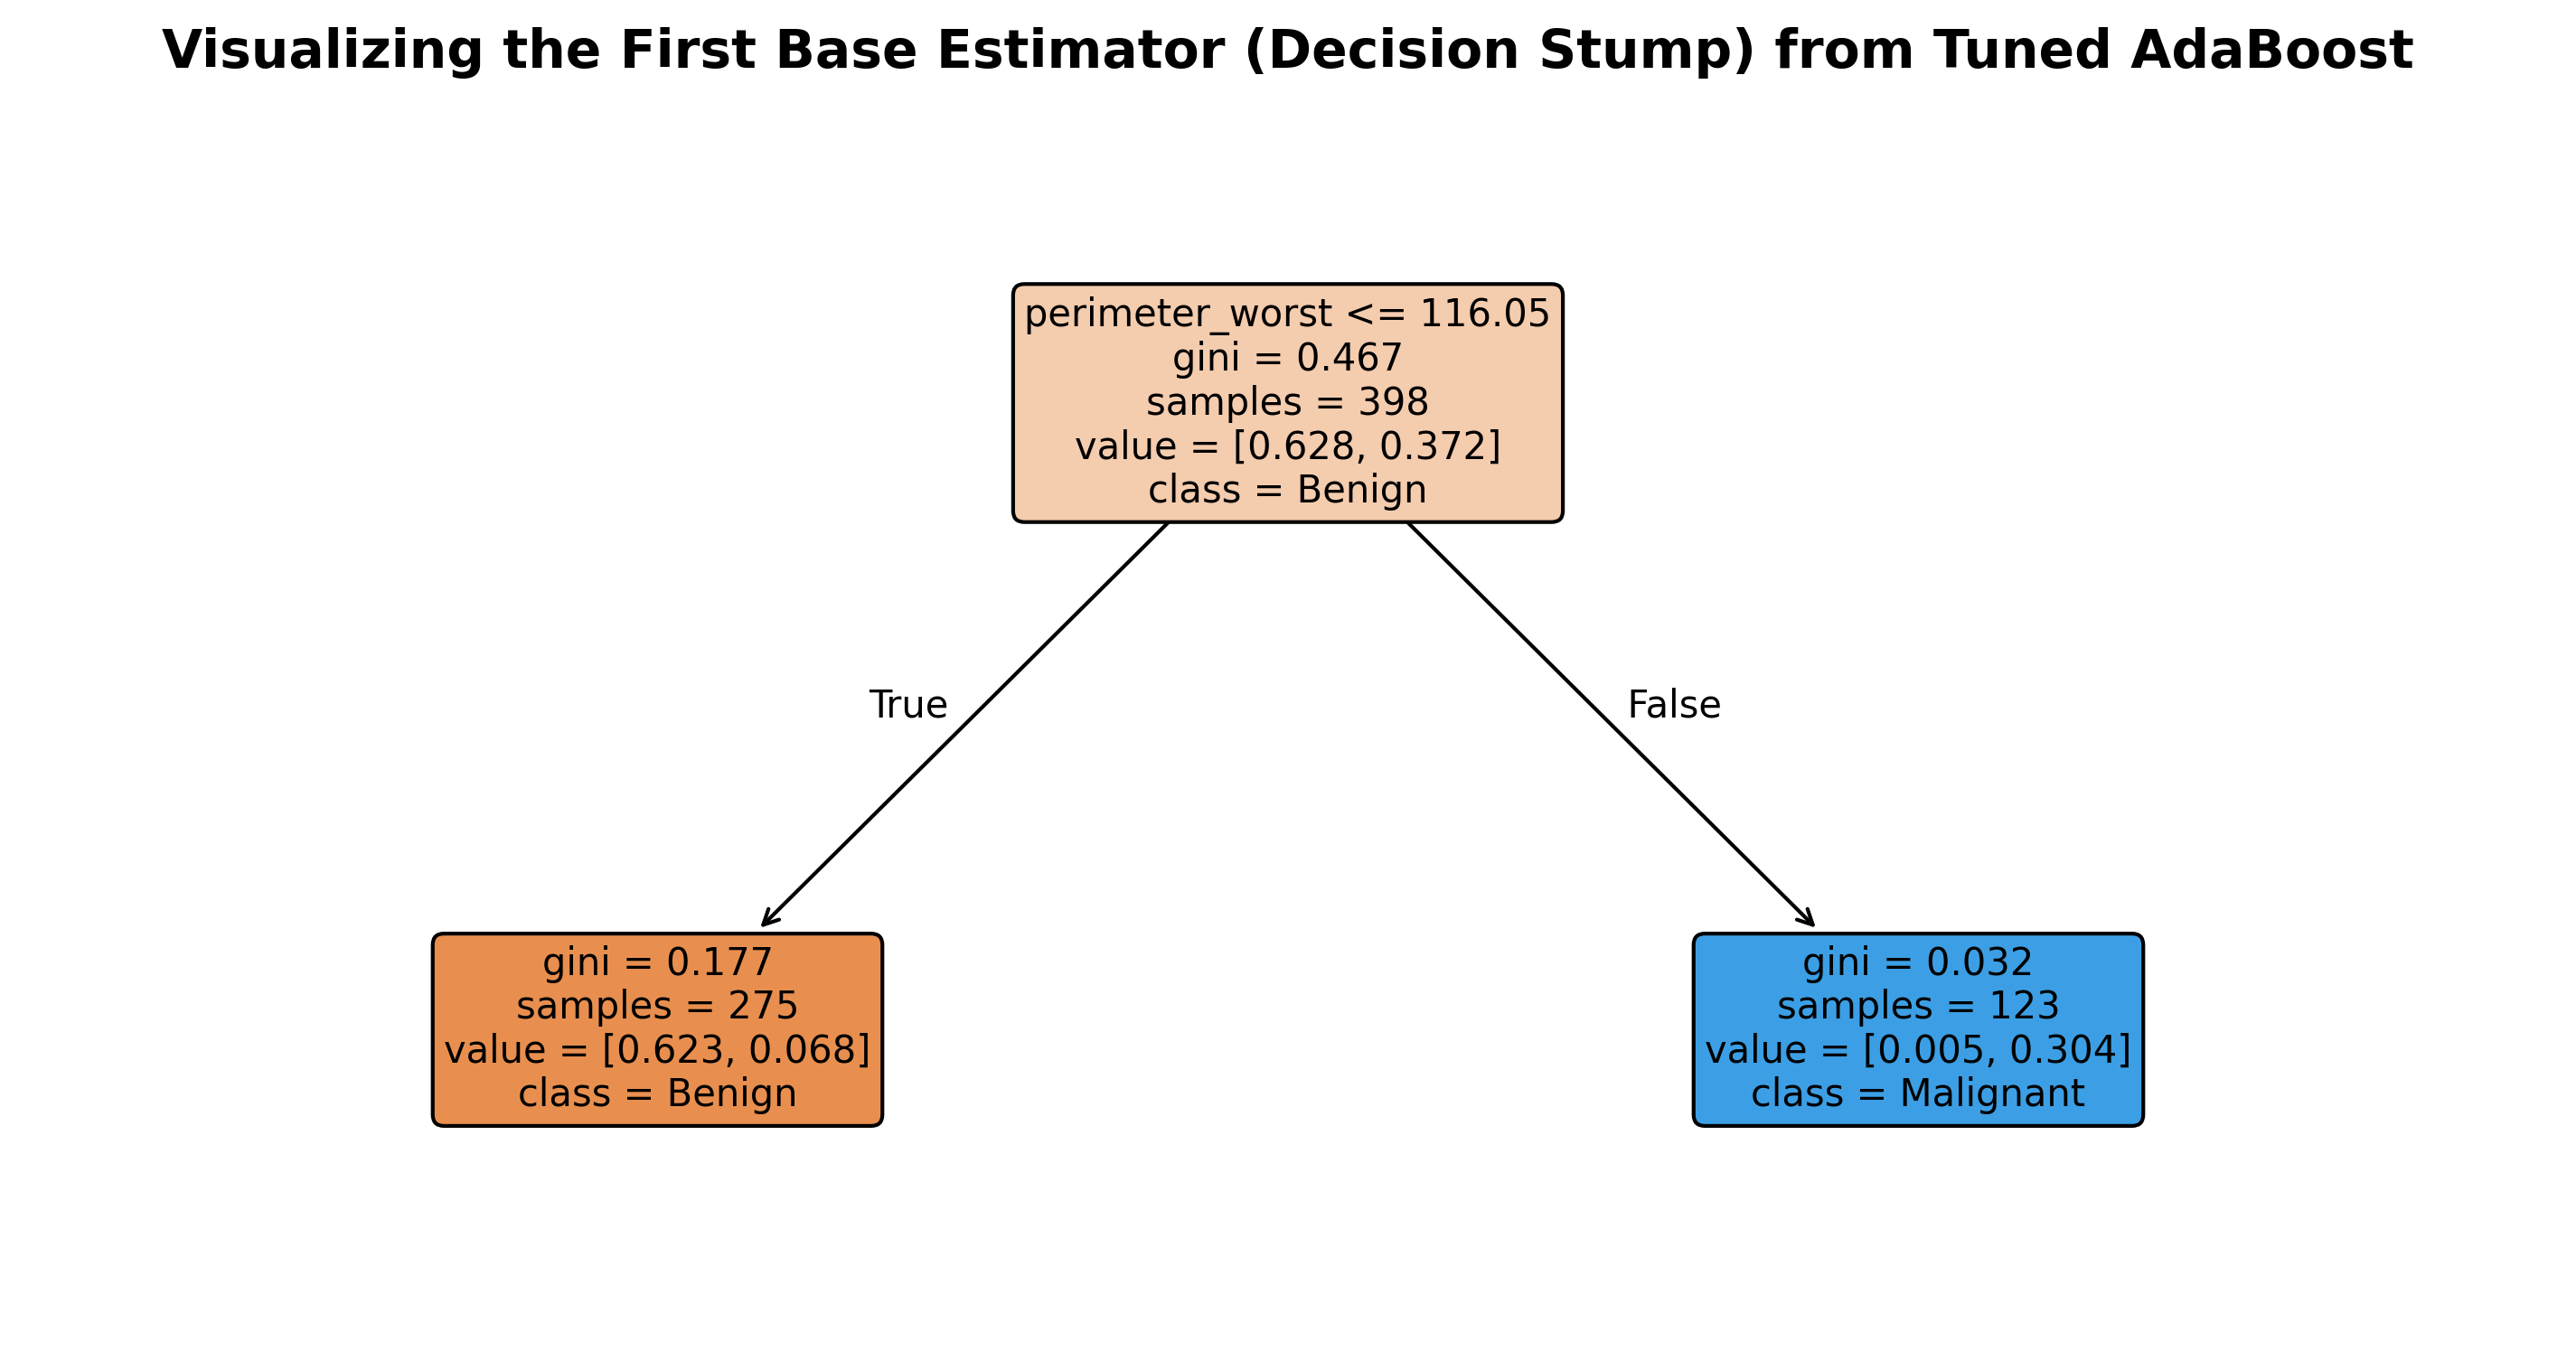

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Configure a customized figure size for the AdaBoost base estimator
plt.figure(figsize=(12, 6), dpi=300)

# Extract the very first base estimator (decision stump) from the tuned AdaBoost model
first_ada_estimator = best_ada.estimators_[0]

# Plot the tree
plot_tree(
    first_ada_estimator,
    feature_names=feature_cols,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Visualizing the First Base Estimator (Decision Stump) from Tuned AdaBoost", fontsize=14, fontweight='bold')
plt.show()

XGBoost

In [36]:
from xgboost import XGBClassifier

# 1. Baseline XGBoost with default settings
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)
print("Baseline XGBoost:")
print("Train accuracy:", accuracy_score(y_train, xgb_base.predict(X_train)))
print("Test accuracy: ", accuracy_score(y_test, xgb_base.predict(X_test)))
print("Number of estimators:", xgb_base.n_estimators)

Baseline XGBoost:
Train accuracy: 1.0
Test accuracy:  0.9298245614035088
Number of estimators: None


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [00:05:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
# 2. Setup GridSearchCV for XGBoost
xgb_params = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

gs_xgb = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_params,
    scoring={"accuracy": "accuracy", "recall": "recall", "f1": "f1"},
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
gs_xgb.fit(X_train, y_train)

print("Best params:", gs_xgb.best_params_)
print("Best CV F1 :", round(gs_xgb.best_score_, 4))

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV F1 : 0.9623


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [00:08:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
# 3. Evidence of best parameters
res_xgb = pd.DataFrame(gs_xgb.cv_results_)
cols_xgb = ["params", "mean_test_f1", "std_test_f1", "mean_test_recall",
            "mean_test_accuracy", "mean_train_f1", "rank_test_f1"]

pd.set_option("display.max_colwidth", 120)
print("--- Top 10 XGBoost Configurations by F1 Score ---")
display(res_xgb.sort_values("rank_test_f1").head(10)[cols_xgb].round(4))

--- Top 10 XGBoost Configurations by F1 Score ---


,params,mean_test_f1,std_test_f1,mean_test_recall,mean_test_accuracy,mean_train_f1,rank_test_f1
94,"{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}",0.9623,0.0288,0.9529,0.9724,0.9970,1
298,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9966,2
302,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9996,2
300,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9992,2
308,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9989,2
306,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9966,2
314,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9966,2
316,"{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}",0.9595,0.0288,0.9595,0.9698,0.9989,2
247,"{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 1.0}",0.9595,0.0324,0.9529,0.9699,0.9966,9
245,"{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}",0.9595,0.0324,0.9529,0.9699,0.9966,9


In [39]:
# 4. Final Evaluation on Holdout Test Set
best_xgb = gs_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("XGBoost Model Report:")
print("accuracy = " + str(accuracy_score(y_test, y_pred_xgb)))
print(classification_report(y_test, y_pred_xgb, target_names=["Benign", "Malignant"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("Baseline Recall:", round(recall_score(y_test, xgb_base.predict(X_test)), 4),
      "| Tuned Recall:", round(recall_score(y_test, y_pred_xgb), 4))

XGBoost Model Report:
accuracy = 0.9239766081871345
              precision    recall  f1-score   support

      Benign       0.91      0.97      0.94       107
   Malignant       0.95      0.84      0.89        64

    accuracy                           0.92       171
   macro avg       0.93      0.91      0.92       171
weighted avg       0.93      0.92      0.92       171

Confusion Matrix:
[[104   3]
 [ 10  54]]
Baseline Recall: 0.875 | Tuned Recall: 0.8438


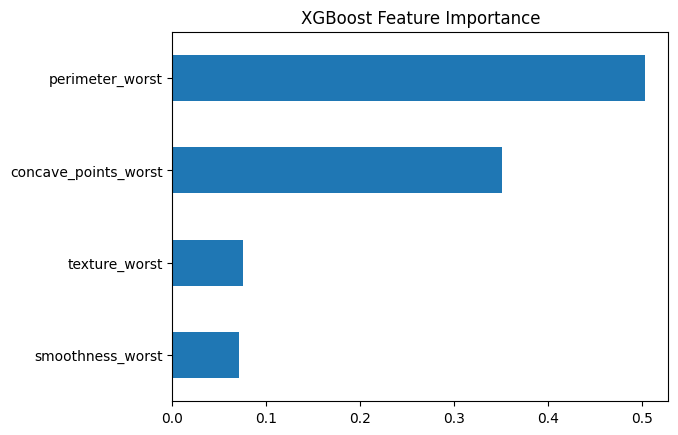

In [40]:
# 5. Feature Importances
pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values().plot.barh(title="XGBoost Feature Importance")
plt.show()

/usr/local/lib/python3.13/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` instead. 
  warnings.warn(


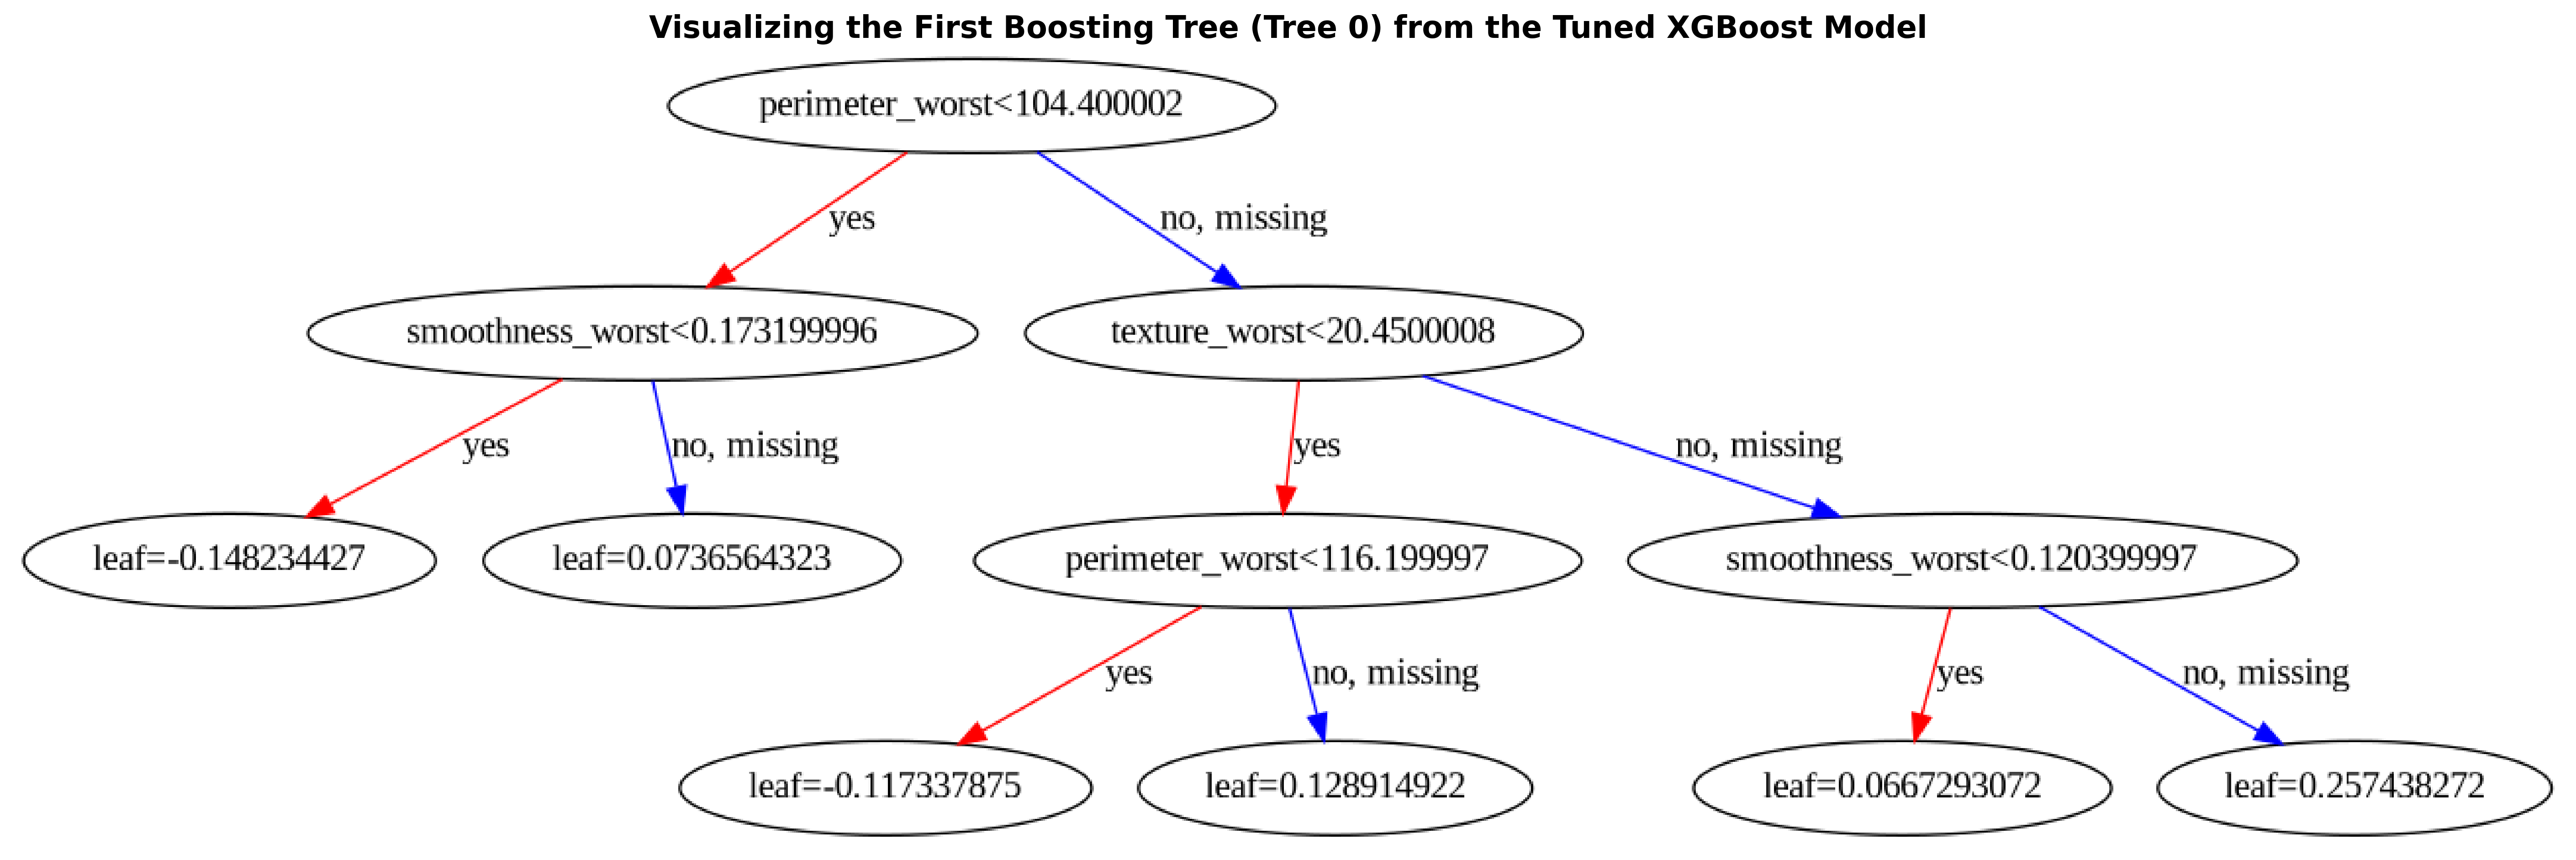

In [49]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Configure figure size and high resolution
fig, ax = plt.subplots(figsize=(24, 12), dpi=300)

# Plot the first tree (index 0) of the tuned XGBoost model
xgb.plot_tree(best_xgb, num_trees=0, ax=ax, fmap='')

plt.title("Visualizing the First Boosting Tree (Tree 0) from the Tuned XGBoost Model", fontsize=16, fontweight='bold')
plt.show()

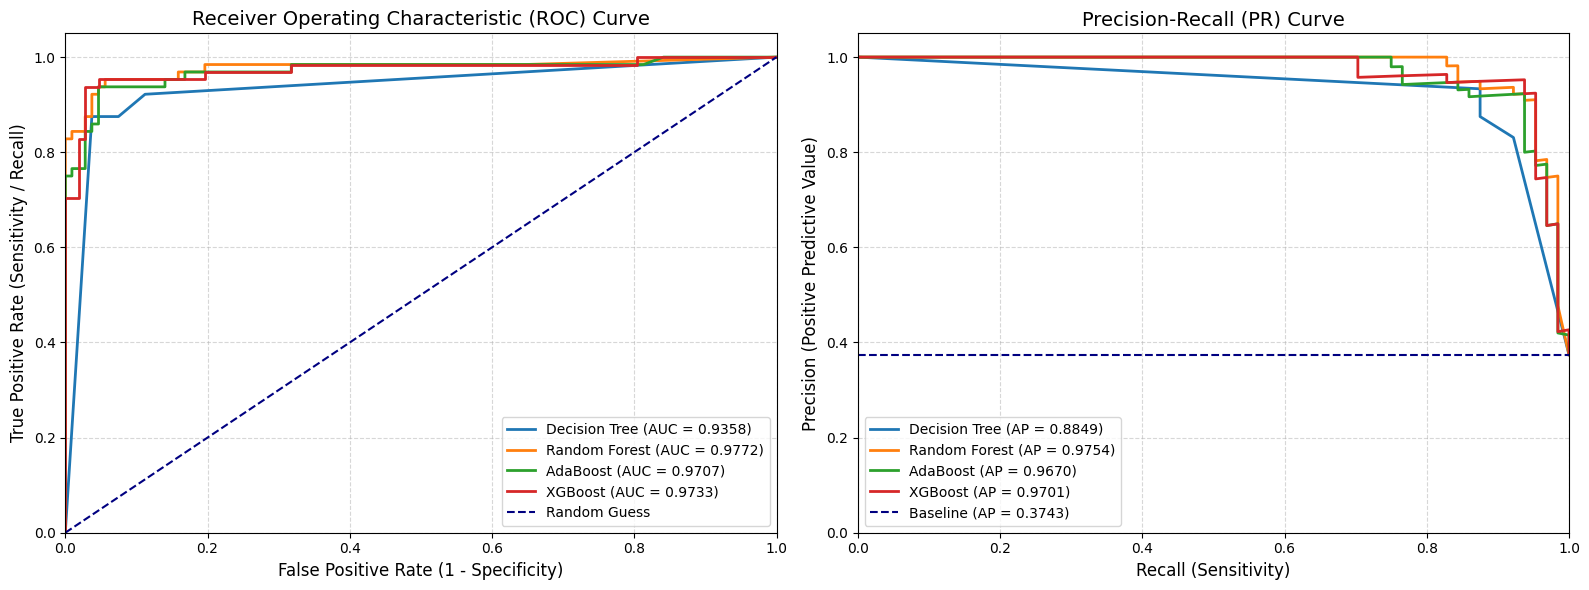

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Dictionary of our best models
models = {
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'AdaBoost': best_ada,
    'XGBoost': best_xgb
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC Curves
for name, model in models.items():
    # Get probability predictions for class 1 (Malignant)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', lw=2)

ax1.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
ax1.legend(loc="lower right")
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot Precision-Recall Curves
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    avg_precision = average_precision_score(y_test, y_probs)
    ax2.plot(recall, precision, label=f'{name} (AP = {avg_precision:.4f})', lw=2)

# Baseline is the proportion of positive instances (malignant cases) in test set
baseline = sum(y_test) / len(y_test)
ax2.axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline (AP = {baseline:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax2.set_title('Precision-Recall (PR) Curve', fontsize=14)
ax2.legend(loc="lower left")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [42]:
print("--- AUC-ROC Scores on Holdout Test Set ---")
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    print(f"{name:<15} : {roc_auc:.4f}")

--- AUC-ROC Scores on Holdout Test Set ---
Decision Tree   : 0.9358
Random Forest   : 0.9772
AdaBoost        : 0.9707
XGBoost         : 0.9733


In [44]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_curve, auc

# Initialize lists to store model statistics
metrics_summary = []

for name, model in models.items():
    # Predict binary targets
    y_pred = model.predict(X_test)

    # Get decision outputs/probabilities for AUC calculation
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    # Compute individual metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred) # Recall for class 1 (Malignant)
    f1 = f1_score(y_test, y_pred)      # F1-Score for class 1 (Malignant)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Store in summary structure
    metrics_summary.append({
        "Model": name,
        "Accuracy": f"{acc:.4f}",
        "Recall (Malignant)": f"{rec:.4f}",
        "F1-Score (Malignant)": f"{f1:.4f}",
        "AUC-ROC": f"{roc_auc:.4f}"
    })

# Convert to a DataFrame and display
summary_df = pd.DataFrame(metrics_summary)
display(summary_df)

,Model,Accuracy,Recall (Malignant),F1-Score (Malignant),AUC-ROC
0,Decision Tree,0.9240,0.8750,0.8960,0.9358
1,Random Forest,0.9298,0.8750,0.9032,0.9772
2,AdaBoost,0.9181,0.8281,0.8833,0.9707
3,XGBoost,0.9240,0.8438,0.8926,0.9733


```markdown
## How to Determine Which Model is Best?

To figure out which machine learning model is the "best," we must evaluate them through multiple lenses depending on our dataset and real-world application (breast cancer diagnosis).

### 1. Overall Discriminative Power: **AUC-ROC**
* **What it measures:** The probability that the model ranks a random malignant instance higher than a random benign instance across all thresholds.
* **Results on our holdout test set:**
  * **Random Forest:** **0.9772** (Best)
  * **XGBoost:** **0.9733**
  * **AdaBoost:** **0.9707**
  * **Decision Tree:** **0.9358**
* **Verdict:** Under this traditional metric, **Random Forest** has the highest overall classification power, closely followed by **XGBoost**.

### 2. Clinical Priority: **Recall (Sensitivity)**
* **What it measures:** Out of all actual malignant cases, how many did we correctly find? In medical diagnosis, a **False Negative** (missing cancer) is much more dangerous than a **False Positive** (additional testing required). Therefore, **high recall is paramount**.
* **Test Set Recall:**
  * **Decision Tree:** **0.8750** (7 false negatives out of 64)
  * **Random Forest:** **0.8750** (7 false negatives out of 64)
  * **XGBoost:** **0.8438** (10 false negatives out of 64)
  * **AdaBoost:** **0.8281** (11 false negatives out of 64)
* **Verdict:** Even though ensemble models had higher AUC, the tuned **Random Forest** and **Decision Tree** models actually caught the highest proportion of malignant tumors on this specific test set.

### 3. Precision-Recall Trade-off: **Average Precision (AP)**
* **What it measures:** Captures both high precision (few false alarms) and high recall (few missed diagnoses) across different probability thresholds.
* **Verdict:** Looking at the plotted Precision-Recall curves, **XGBoost** and **Random Forest** maintain extremely high precision (close to 95%+) even when matching high levels of recall.

### Conclusion
* **The Overall Best Model is the Random Forest Classifier.** It offers the highest generalizability (highest AUC-ROC), keeps overfitting under control, and ties for the highest Recall/Sensitivity (87.50%) on our test set.
```